### IMPORTACIONES

In [ ]:
import pandas as pd
import numpy as np
import json
import os, zipfile
from collections import Counter, OrderedDict
from pprint import pprint
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, 
    cross_val_score, KFold
)
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, SelectPercentile, GenericUnivariateSelect,
    SelectFpr, SelectFdr, chi2, f_classif, mutual_info_classif,
    RFE, RFECV, SequentialFeatureSelector, SelectFromModel
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, make_scorer, 
    classification_report, confusion_matrix
)


### CARGA DATOS

In [ ]:
path = "data/salario.csv"
df = pd.read_csv(path)
df.head(5)

,edad,trabajo,estudios,estado-civil,trabajo.1,posicion-familiar,etnia,sexo,ganancias_inversiones,perdidas_inversiones,horas-trabajo_semana,pais-origen,salario
0,39,State-gov,Bachelors,Never-married,Adm-clerical,No-en-familia,Blanco,Hombre,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Marido,Blanco,Hombre,0,0,13,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,No-en-familia,Blanco,Hombre,0,0,40,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Marido,Negro,Hombre,0,0,40,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Mujer,Negro,Mujer,0,0,40,Cuba,<=50K


In [ ]:
path2 = "data/salario_test.csv"
df_test = pd.read_csv(path2)
df_test.head(5)

,ID,edad,trabajo,estudios,estado-civil,trabajo.1,posicion-familiar,etnia,sexo,ganancias_inversiones,perdidas_inversiones,horas-trabajo_semana,pais-origen
0,1,36,Private,Assoc-acdm,Never-married,Tech-support,No-en-familia,Blanco,Mujer,0,0,40,United-States
1,2,21,Private,HS-grad,Never-married,Adm-clerical,Otro-familiar,Blanco,Mujer,0,0,45,United-States
2,3,30,Private,HS-grad,Separated,Farming-fishing,Soltero-a,Blanco,Mujer,0,0,14,United-States
3,4,46,Private,Some-college,Married-civ-spouse,Craft-repair,Marido,Blanco,Hombre,0,0,40,United-States
4,5,32,Private,5th-6th,Married-civ-spouse,Machine-op-inspct,Mujer,Asiatico-Pacifico-Isleno,Mujer,0,0,40,Laos


Vamos a trabajar sobre estos 2 archivos csv:

### salario.csv

* Trae *features* + la etiqueta salario (<=50K / >50K).
* Con este archivo:
    * **Limpiamos y ajustamos (*fit*) todo:** imputaciones, One-Hot, escalados;
    * **Entrenamos** el modelo;
    * **Hacemos validación** (*train/test split* interno o CV);
    * **Decidimos** cómo balancear (SMOTE) y qué *features* quedarnos (RFECV, etc.).

---

### salario_test.csv = TEST real

* Trae ID + *features*, **sin** columna salario.
* Con este archivo:
    * Solo transformamos con lo aprendido en salario.csv (mismas columnas, mismo One-Hot/scaler/máscara de RFECV);
    * **No hacemos fit**, no hacemos SMOTE/undersampling;
    * **Predecimos** y generamos el archivo de entrega:
        * ID, salario (con etiquetas de texto usando le.inverse_transform).

---


### LIMPIEZA DE DATOS

In [5]:
# Renombrar columnas (trabajo.1 y trabajo por palabras que describan mejor lo que representa las columnas)
df = df.rename(columns={'trabajo.1': 'sector', 'trabajo': 'tipo_trabajo'})

# Eliminar espacios en blanco en las columnas de tipo 'object'
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

# Reemplazar '?' por NaN (no hay valores nulos, sino que aparecen '?' en su lugar)
df = df.replace('?', np.nan)

# Imputación: Usaremos la moda para rellenar los valores perdidos en las columnas categóricas
for col in ['tipo_trabajo', 'sector', 'pais-origen']:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

# Separar características (X) y variable objetivo (y)
X = df.drop(columns='salario')
y = df['salario']

# Preprocesamiento de la variable objetivo (Label Encoding: <=50K -> 0, >50K -> 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

C:\Users\jenni\AppData\Local\Temp\ipykernel_27444\3278329211.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)


In [ ]:
# LIMPIEZA DE DATOS (TEST) 

# Renombrar columnas como en train
df_test = df_test.rename(columns={'trabajo.1': 'sector', 'trabajo': 'tipo_trabajo'})

# Strip de espacios en textos
for col in df_test.select_dtypes(include=['object']).columns:
    df_test[col] = df_test[col].str.strip()

# Reemplazar '?' por NaN
df_test = df_test.replace('?', np.nan)

# Imputar sólo con las modas aprendidas en train 
modes_train = {
    'tipo_trabajo': df['tipo_trabajo'].mode()[0],
    'sector':       df['sector'].mode()[0],
    'pais-origen':  df['pais-origen'].mode()[0],
}
for c, v in modes_train.items():
    if c in df_test.columns:
        df_test[c] = df_test[c].fillna(v)

# Guardar ID y crear X_test (sin la columna ID)
ids_test = df_test['ID'].copy() 
X_test_kaggle = df_test.drop(columns=['ID'])

print("X_test shape:", X_test_kaggle.shape)
X_test_kaggle.head()


X_test shape: (4563, 12)


,edad,tipo_trabajo,estudios,estado-civil,sector,posicion-familiar,etnia,sexo,ganancias_inversiones,perdidas_inversiones,horas-trabajo_semana,pais-origen
0,36,Private,Assoc-acdm,Never-married,Tech-support,No-en-familia,Blanco,Mujer,0,0,40,United-States
1,21,Private,HS-grad,Never-married,Adm-clerical,Otro-familiar,Blanco,Mujer,0,0,45,United-States
2,30,Private,HS-grad,Separated,Farming-fishing,Soltero-a,Blanco,Mujer,0,0,14,United-States
3,46,Private,Some-college,Married-civ-spouse,Craft-repair,Marido,Blanco,Hombre,0,0,40,United-States
4,32,Private,5th-6th,Married-civ-spouse,Machine-op-inspct,Mujer,Asiatico-Pacifico-Isleno,Mujer,0,0,40,Laos


In [ ]:
#df_test no tiene variable objetivo ("salario"), el test solo tiene ID + features; la etiqueta real se guarda para evaluar tus predicciones.
#En test no existe y (no hay nada que codificar (LabelEncoder), entrenar modelos ni con lo que calcular métricas localmente((F1, accuracy) comparando predicción vs. verdad)).
# El LabelEncoder (le) solo se usa para la y del train (mapear <=50K/>50K a  0/1). En test no se hace fit de nada; como máximo usaremos le.inverse_transform para convertir las predicciones (0/1) a etiquetas de texto antes de generar el CSV de envío.

In [ ]:
#No podemos calcular métricas locales porque nos falta la “respuesta correcta” para comparar.

#Lo único correcto es transformar con lo aprendido en train y predecir (df_test sirve para predecir con lo aprendido en df: ajustamos (fit) todo con df y 
# solo transformamos df_test, luego realizamos predicciones sobre df_test.)

### PREPROCESAMIENTO (split + Outliers + OHE)

In [ ]:
#Split estratificado (no transformarmos antes del split)
#Si lo hiciéramos antes del split, estaríamos introduciendo fuga de datos (data leakage):
#Los transformadores “aprenden” del conjunto completo. Si hacemos fit con todo X, usaríamos información del futuro (test) para preparar el entrenamiento.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

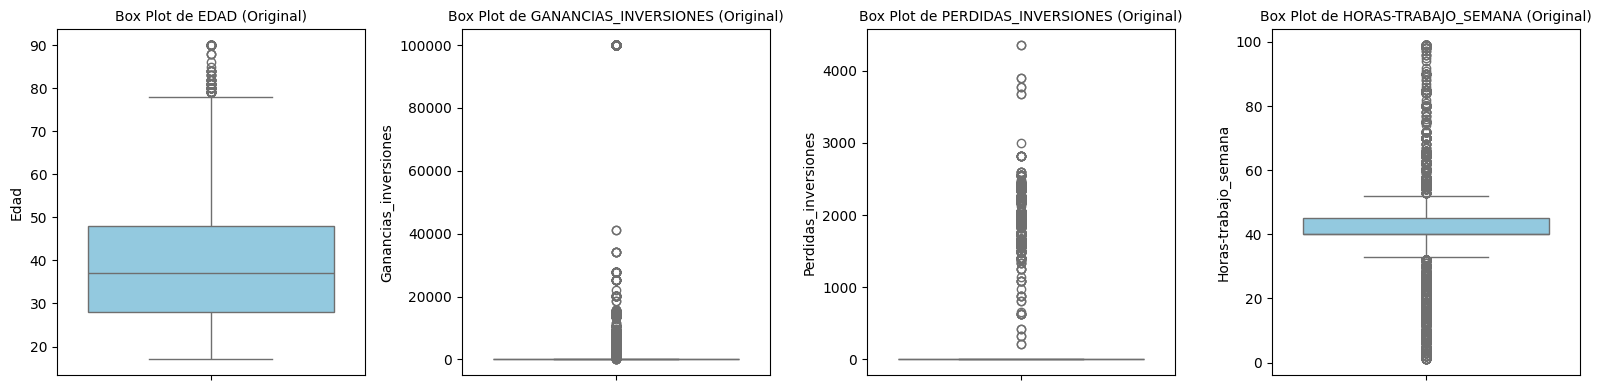

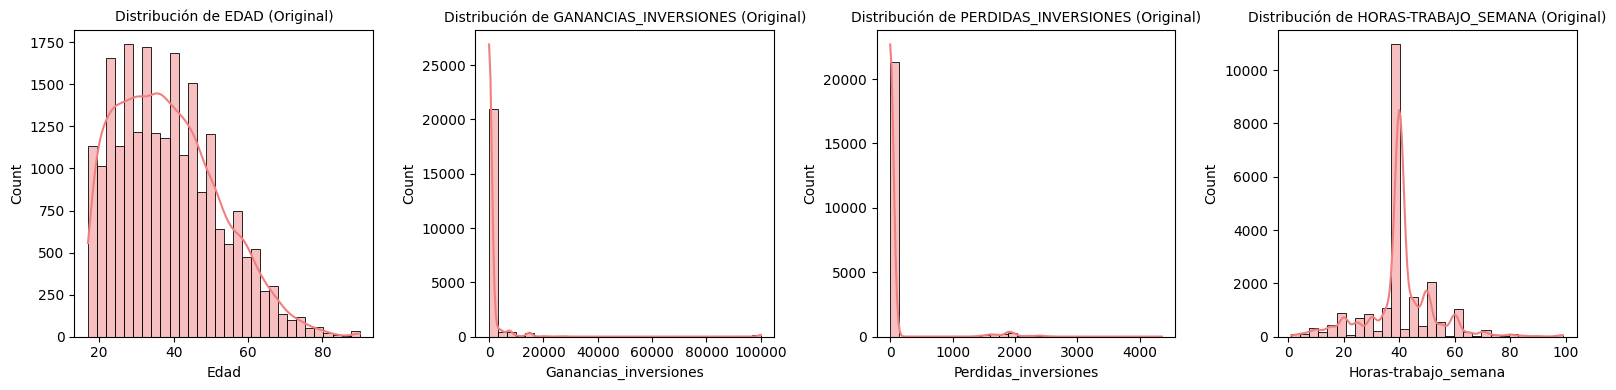

In [ ]:
# VISUALIZACIÓN DE OUTLIERS (Box Plot e Histogramas)

numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Box Plots: Muestran la mediana, cuartiles y los outliers como puntos
plt.figure(figsize=(16, 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i + 1)
    # Graficamos el conjunto de entrenamiento antes de tratarlo
    sns.boxplot(y=X_train[col], color='skyblue') 
    plt.title(f'Box Plot de {col.upper()} (Original)', fontsize=10)
    plt.ylabel(col.capitalize())
plt.tight_layout()
plt.show() 

# Histogramas: Muestran la asimetría causada por los valores extremos
plt.figure(figsize=(16, 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i + 1)
    sns.histplot(X_train[col], kde=True, bins=30, color='lightcoral')
    plt.title(f'Distribución de {col.upper()} (Original)', fontsize=10)
    plt.xlabel(col.capitalize())
plt.tight_layout()
plt.show() 

In [ ]:
# DETECCIÓN Y TRATAMIENTO DE OUTLIERS (Solo en X_train)

# Identificar columnas numéricas (antes de OHE)
numerical_cols_raw = X_train.select_dtypes(include=np.number).columns.tolist()
    
# Definir los cuantiles de corte (p. ej., 5% y 95%)
lower_bound = 0.05
upper_bound = 0.95

for col in numerical_cols_raw:

    # Calcular los límites de los cuantiles en el conjunto de entrenamiento
    q_low = X_train[col].quantile(lower_bound)
    q_high = X_train[col].quantile(upper_bound)
    
    # Winsorización (aplicar los límites de train a train y test)
    # Reemplazar valores de X_train fuera del rango por los límites del cuantil
    X_train[col] = np.where(X_train[col] < q_low, q_low, X_train[col])
    X_train[col] = np.where(X_train[col] > q_high, q_high, X_train[col])
    
    # Aplicar los mismos límites aprendidos en X_train a X_test
    # Esto evita la fuga de datos (data leakage)
    X_test[col] = np.where(X_test[col] < q_low, q_low, X_test[col])
    X_test[col] = np.where(X_test[col] > q_high, q_high, X_test[col])


## Justificación del Tratamiento de Outliers (Winsorización)
Elegimos la Winsorización al 5%-95% en las features numéricas para estabilizar los datos de cara a modelos sensibles como la Regresión Logística.

La Regresión Logística y el escalado son muy sensibles a los valores extremos (outliers), que pueden sesgar gravemente los coeficientes.

Limitamos los valores extremos (del 5% inferior y 5% superior) al valor de sus respectivos cuantiles (5% y 95%). Así, neutralizamos el impacto de los outliers sin eliminar filas de información. Los límites de Winsorización se calculan solo en X_train y luego se aplican a X_test, asegurando una validación justa.

In [ ]:
# Columnas numéricas y categóricas
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()

# Preprocesador base: solo OHE para categóricas, 'passthrough' para numéricas (todavía no escalamos)
preprocessor_base = ColumnTransformer(
    transformers=[
        # Las numéricas se pasan sin escalar ('passthrough')
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

# Ajustar solo con TRAIN y transformar TRAIN/TEST (solo OHE y pasar numéricas sin escalar) (el escalado se aplica después)
preprocessor_base.fit(X_train)
X_train_proc = preprocessor_base.transform(X_train)
X_test_proc  = preprocessor_base.transform(X_test)

feature_names = preprocessor_base.get_feature_names_out()

# DataFrames finales (mantienen los índices originales)
X_train_processed_df = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train.index)
X_test_processed_df  = pd.DataFrame(X_test_proc,  columns=feature_names, index=X_test.index)

print("Shapes -> train:", X_train_processed_df.shape, " test:", X_test_processed_df.shape)

Shapes -> train: (22398, 103)  test: (5600, 103)


In [ ]:
# PREPROCESAMIENTO (TEST) con el preprocessor_base ajustado en train 

# Transformar test (OHE en cat + passthrough en num)
X_test_kaggle_proc = preprocessor_base.transform(X_test_kaggle)

# Nombres de columnas como en train
feature_names = preprocessor_base.get_feature_names_out()



# DataFrame final de salario_test (no el test de validación interna de salario.csv) ya preprocesado
X_test_kaggle_df = pd.DataFrame(X_test_kaggle_proc, columns=feature_names, index=df_test.index)
print("Shapes -> test:", X_test_kaggle_df.shape)


Shapes -> test: (4563, 103)


In [58]:
X_test_kaggle_df.head()

,num__edad,num__ganancias_inversiones,num__perdidas_inversiones,num__horas-trabajo_semana,cat__tipo_trabajo_Federal-gov,cat__tipo_trabajo_Local-gov,cat__tipo_trabajo_Never-worked,cat__tipo_trabajo_Private,cat__tipo_trabajo_Self-emp-inc,cat__tipo_trabajo_Self-emp-not-inc,...,cat__pais-origen_Portugal,cat__pais-origen_Puerto-Rico,cat__pais-origen_Scotland,cat__pais-origen_South,cat__pais-origen_Taiwan,cat__pais-origen_Thailand,cat__pais-origen_Trinadad&Tobago,cat__pais-origen_United-States,cat__pais-origen_Vietnam,cat__pais-origen_Yugoslavia
0,36.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,21.0,0.0,0.0,45.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,30.0,0.0,0.0,14.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,46.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,32.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Correlación entre features numéricas después de Winsorización:

Generando Heatmap de Correlación Numérica...


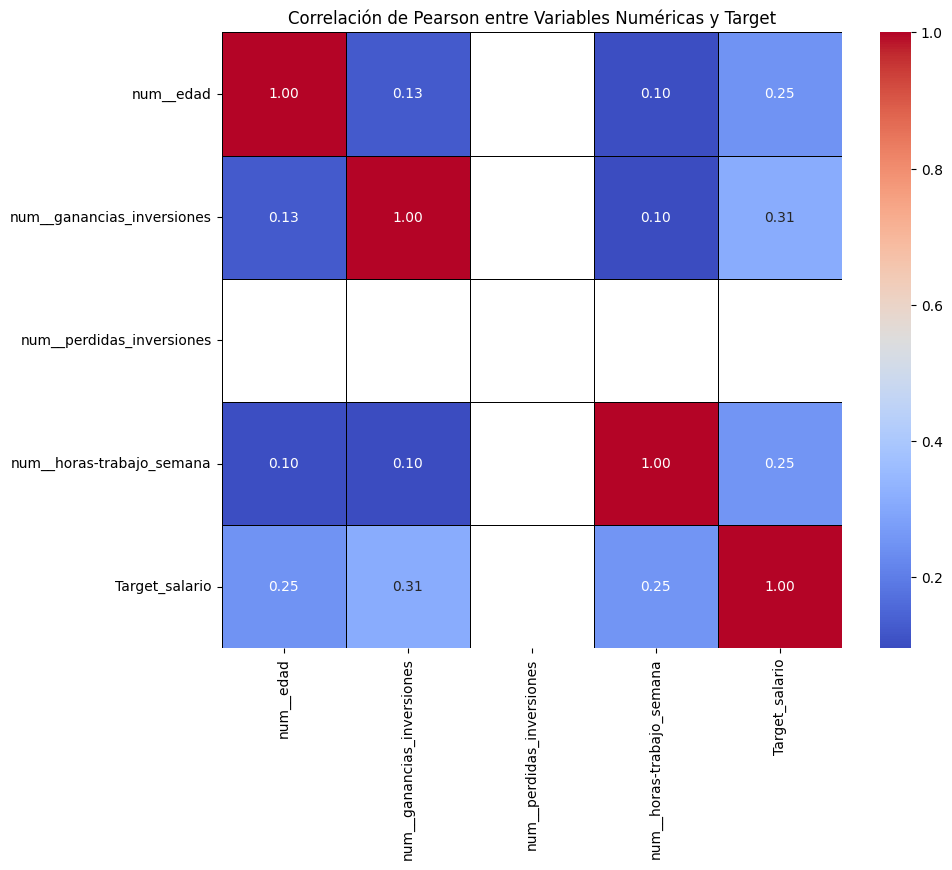

El valor numérico de la correlación es: nan
Varianza de num__edad: 164.556418773047
Varianza de num__perdidas_inversiones: 0.0


In [ ]:
# 'num_cols' contiene los nombres de tus columnas numéricas.
num_cols = [c for c in X_train_processed_df.columns if c.startswith("num__")]
print("Generando Heatmap de Correlación Numérica...")

# Crear un DataFrame para el análisis de correlación, incluyendo el Target
# Esto asume que y_train está alineado con X_train_processed_df
df_corr = X_train_processed_df[num_cols].copy()
df_corr['Target_salario'] = y_train 

# Calcular la matriz de correlación (Pearson)
corr_matrix = df_corr.corr()

# Graficar el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    linewidths=0.5,
    linecolor='black'
)
plt.title('Correlación de Pearson entre Variables Numéricas y Target')
plt.show()

En este punto nos damos cuenta de que algo pasa con la columna 'num__perdidas_inversiones' ya que todas sus correlaciones con el resto de columnas es nan (su varianza es 0 porque sus datos son muy dispersos y la mayoría (+25000) son 0 -> lo mismo pasa con num__ganancias_inversiones)

In [ ]:
# Crear el DataFrame de correlación incluyendo solo las dos variables
df_corr_specific = X_train_processed_df[['num__edad', 'num__perdidas_inversiones']].copy()

# Calcular la matriz de correlación
corr_matrix_specific = df_corr_specific.corr()

# Acceder al valor numérico específico
correlacion = corr_matrix_specific.loc['num__perdidas_inversiones', 'num__edad']

print(f"El valor numérico de la correlación es: {correlacion:.6f}")
print("Varianza de num__edad:", X_train_processed_df['num__edad'].var())
print("Varianza de num__perdidas_inversiones:", X_train_processed_df['num__perdidas_inversiones'].var())

### DESBALANCEO DE CLASES

In [60]:
# Verificar el desbalance de clases en la variable objetivo
class_counts = df['salario'].value_counts(normalize=True) * 100

print("\n Distribución de la clase 'salario' ")
print(class_counts)

# Si el desbalance es significativo (ej. una clase es < 25%), 
# consideraremos técnicas como SMOTE, sobre/submuestreo, o ajustes 
# en los pesos de clase (class_weight) del modelo.


 Distribución de la clase 'salario' 
salario
<=50K    76.041146
>50K     23.958854
Name: proportion, dtype: float64


Una clase conforma el 24% del total (que es menor que el 25%). Por tanto, vamos a aplicar el sobremuestreo/oversampling:

El sobremuestreo/undersampling solo se hace sobre train para no sesgar la evaluación ni crear datos nuevos en test. Tenemos dos opciones para oversampling: SMOTE y RandomOverSampler. RandomOverSampler duplica aleatoriamente muestras de la clase minoritaria, mientras que SMOTE genera nuevas muestras sintéticas interpolando entre las existentes. Podemos usar cualquiera de los dos métodos, pero SMOTE suele ser preferido ya que introduce más diversidad en los datos sintéticos generados. Además, SMOTE puede ayudar a reducir el sobreajuste al crear nuevas muestras en lugar de simplemente duplicar las existentes. Por tanto, usaremos SMOTE para el sobremuestreo en este caso.

In [ ]:
!pip install imbalanced-learn


[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Usando SMOTE (se aplica sobre datos ya one-hot)
# Funciona así:
# 1. Elige una muestra de la clase minoritaria.
# 2. Encuentra a sus "vecinos" más cercanos (otras muestras minoritarias).
# 3. Crea una nueva muestra sintética en un punto aleatorio entre la muestra original y uno de sus vecinos.
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed_df, y_train)
print("Tras SMOTE:", Counter(y_train_smote))

Original (train): Counter({0: 17032, 1: 5366})
Tras RandomOverSampler: Counter({0: 17032, 1: 17032})
Tras SMOTE: Counter({0: 17032, 1: 17032})


In [64]:
X_train_bal, y_train_bal = X_train_smote, y_train_smote

No usamos **undersampling** porque en nuestro caso la clase mayoritaria representa ~76% y la minoritaria ~24%. Recortar la mayoritaria para equilibrar implicaría: descartar mucha información (perder variabilidad y patrones) y degradar la generalización, volviendo al modelo inestable.

Además, con muchas variables categóricas (tras one-hot), técnicas de **undersampling** pueden eliminar ejemplos útiles cerca de la frontera.

Como no tenemos un problema de coste computacional, preferimos **oversampling** (RandomOverSampler/SMOTE), que conservan todos los datos y equilibran el aprendizaje sin sacrificar información.

In [65]:
X_train_bal.head()

,num__edad,num__ganancias_inversiones,num__perdidas_inversiones,num__horas-trabajo_semana,cat__tipo_trabajo_Federal-gov,cat__tipo_trabajo_Local-gov,cat__tipo_trabajo_Never-worked,cat__tipo_trabajo_Private,cat__tipo_trabajo_Self-emp-inc,cat__tipo_trabajo_Self-emp-not-inc,...,cat__pais-origen_Portugal,cat__pais-origen_Puerto-Rico,cat__pais-origen_Scotland,cat__pais-origen_South,cat__pais-origen_Taiwan,cat__pais-origen_Thailand,cat__pais-origen_Trinadad&Tobago,cat__pais-origen_United-States,cat__pais-origen_Vietnam,cat__pais-origen_Yugoslavia
0,50.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,56.0,4874.9,0.0,50.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,32.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,23.0,0.0,0.0,48.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,30.0,0.0,0.0,60.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [66]:
y_train_bal

array([0, 1, 0, ..., 1, 1, 1])

### SELECCIÓN DE CARACTERÍSTICAS

In [67]:
X_train_bal.head()

,num__edad,num__ganancias_inversiones,num__perdidas_inversiones,num__horas-trabajo_semana,cat__tipo_trabajo_Federal-gov,cat__tipo_trabajo_Local-gov,cat__tipo_trabajo_Never-worked,cat__tipo_trabajo_Private,cat__tipo_trabajo_Self-emp-inc,cat__tipo_trabajo_Self-emp-not-inc,...,cat__pais-origen_Portugal,cat__pais-origen_Puerto-Rico,cat__pais-origen_Scotland,cat__pais-origen_South,cat__pais-origen_Taiwan,cat__pais-origen_Thailand,cat__pais-origen_Trinadad&Tobago,cat__pais-origen_United-States,cat__pais-origen_Vietnam,cat__pais-origen_Yugoslavia
0,50.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,56.0,4874.9,0.0,50.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,32.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,23.0,0.0,0.0,48.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,30.0,0.0,0.0,60.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
# Selección de características (filtro/wrapper/embebido)

X_train_bal = pd.DataFrame(X_train_smote, columns=feature_names)
y_train_bal = pd.Series(y_train_smote, name="salario_encoded")

X_test_df = X_test_processed_df.copy()   # test preprocesado
K = 20                                    # nº de atributos a seleccionar elegido

# Reducimos la Validación Cruzada a CV=3
# para acelerar los métodos Wrapper (RFECV) y la evaluación interna.
# Eliminamos SFS por conllevar un alto coste computacional (antes lo intentamos aplicar, pero tardaba mucho en ejecutar)

# Conjuntos de datos auxiliares según método
# Para wrappers/embebidos lineales conviene estandarizar
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train_bal)

# Para chi² se necesitan features no negativas -> MinMax a todo 
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train_bal)

X_train_std_df    = pd.DataFrame(X_train_std,    columns=X_train_bal.columns, index=X_train_bal.index)
X_train_minmax_df = pd.DataFrame(X_train_minmax, columns=X_train_bal.columns, index=X_train_bal.index)

# Modelo de evaluación rápida (F1) y CV
# Reducimos n_splits de 5 a 3.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
f1 = make_scorer(f1_score)

# Reducimos el max_iter de RL para acelerar la convergencia en las iteraciones de RFE/RFECV.
base_clf = LogisticRegression(max_iter=2000, solver="liblinear") 

def eval_set(feature_list, X_src, y=y_train_bal, clf=base_clf, label=""):
    """Valida por CV=3 con F1 usando solo las columnas seleccionadas."""
    if isinstance(X_src, np.ndarray):
        X_sel = X_src[:, [X_train_bal.columns.get_loc(c) for c in feature_list]]
    else:
        X_sel = X_src[feature_list].values
    scores = cross_val_score(clf, X_sel, y, scoring=f1, cv=cv, n_jobs=-1)
    return scores.mean(), scores.std()

# Selecciones 
selected = {}  

# FILTROS
# Vamos a probar los diferentes métodos de filtro vistos en las diapositivas:
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train_bal)
feat_vt = X_train_bal.columns[vt.get_support()].tolist()
selected["filter_variance"] = feat_vt[:K] if len(feat_vt) > K else feat_vt

skb_chi2 = SelectKBest(score_func=chi2, k=min(K, X_train_bal.shape[1]))
skb_chi2.fit(X_train_minmax, y_train_bal)
selected["filter_chi2"] = X_train_bal.columns[skb_chi2.get_support()].tolist()

skb_f = SelectKBest(score_func=f_classif, k=min(K, X_train_bal.shape[1]))
skb_f.fit(X_train_std, y_train_bal)
selected["filter_f_classif"] = X_train_bal.columns[skb_f.get_support()].tolist()

skb_mi = SelectKBest(score_func=mutual_info_classif, k=min(K, X_train_bal.shape[1]))
skb_mi.fit(X_train_bal, y_train_bal)
selected["filter_mutual_info"] = X_train_bal.columns[skb_mi.get_support()].tolist()

percent = max(5, int(100 * K / X_train_bal.shape[1]))
sp = SelectPercentile(score_func=f_classif, percentile=percent)
sp.fit(X_train_std, y_train_bal)
feat_percentile = X_train_bal.columns[sp.get_support()].tolist()
selected["filter_percentile_f"] = feat_percentile[:K] if len(feat_percentile) > K else feat_percentile

sfpr = SelectFpr(score_func=f_classif, alpha=0.05)
sfpr.fit(X_train_std, y_train_bal)
selected["filter_fpr_f"] = X_train_bal.columns[sfpr.get_support()].tolist()[:K]

sfdr = SelectFdr(score_func=f_classif, alpha=0.05)
sfdr.fit(X_train_std, y_train_bal)
selected["filter_fdr_f"] = X_train_bal.columns[sfdr.get_support()].tolist()[:K]

# WRAPPERS
# Vamos a probar los diferentes métodos de wrapper vistos en las diapositivas:
rfe_lr = RFE(
    estimator=LogisticRegression(max_iter=2000, solver="liblinear"), # max_iter optimizado
    n_features_to_select=K,
    step=max(1, X_train_bal.shape[1] // 10)
)
rfe_lr.fit(X_train_std, y_train_bal)
selected["wrapper_rfe_logreg"] = X_train_bal.columns[rfe_lr.support_].tolist()

rfecv_lr = RFECV(
    estimator=LogisticRegression(max_iter=2000, solver="liblinear"), # max_iter optimizado
    step=max(1, X_train_bal.shape[1] // 10),
    cv=cv, scoring="f1", n_jobs=-1 # cv optimizado
)
rfecv_lr.fit(X_train_std, y_train_bal)
selected["wrapper_rfecv_logreg"] = X_train_bal.columns[rfecv_lr.support_].tolist()


# EMBEBIDOS
# Vamos a probar los diferentes métodos de embebidos vistos en las diapositivas:
sfm_l1 = SelectFromModel(
    LogisticRegression(penalty="l1", solver="liblinear", C=1.0, max_iter=3000),
    threshold="median"
)
sfm_l1.fit(X_train_std, y_train_bal)
feat_sfm_l1 = X_train_bal.columns[sfm_l1.get_support()].tolist()
selected["embedded_logreg_l1"] = feat_sfm_l1[:K] if len(feat_sfm_l1) > K else feat_sfm_l1

sfm_lsvc = SelectFromModel(LinearSVC(penalty="l1", dual=False, C=0.5, max_iter=5000), threshold="median")
sfm_lsvc.fit(X_train_std, y_train_bal)
feat_sfm_lsvc = X_train_bal.columns[sfm_lsvc.get_support()].tolist()
selected["embedded_linearsvc_l1"] = feat_sfm_lsvc[:K] if len(sfm_lsvc.get_support()) > K else feat_sfm_lsvc

rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf.fit(X_train_bal, y_train_bal)
selected["embedded_random_forest"] = pd.Series(rf.feature_importances_, index=X_train_bal.columns)\
                                         .nlargest(K).index.tolist()

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_bal, y_train_bal)
selected["embedded_gradient_boosting"] = pd.Series(gb.feature_importances_, index=X_train_bal.columns)\
                                            .nlargest(K).index.tolist()

# Evaluación rápida (F1 CV=3 con LogisticRegression) 
rows = []
for name, feats in selected.items():
    if len(feats) == 0:
        rows.append((name, 0, 0.0, 0.0))
        continue
    mu, sd = eval_set(feats, X_train_std)
    rows.append((name, len(feats), mu, sd))

scores_df = pd.DataFrame(rows, columns=["method", "n_features", "f1_mean_cv", "f1_std_cv"])\
             .sort_values(by="f1_mean_cv", ascending=False)

print("\n TOP métodos por F1 (CV=3, LR) ")
print(scores_df.head(10).to_string(index=False))

print("\n Ejemplo de features (primeros 5 por método)")
for k, v in selected.items():
    print(f"{k:>26}: {v[:5]} (+{max(0,len(v)-5)} más)")

c:\Users\jenni\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [2] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\jenni\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


El ganador en la selección de features es el método RFECV con Regresión Logística (RL).

Este método es el mejor para nuestra tarea:

Es un Wrapper: Obliga a la Regresión Logística (RL) a entrenar repetidamente. En cada paso, elimina la feature que menos le ayuda a la RL, y se queda solo con las que de verdad mejoran el rendimiento.

Optimiza la Métrica F1-score: Lo hace fijándose siempre en el F1-score (la métrica utilizada en la competición) y usando Validación Cruzada (CV), así que la selección ya viene optimizada para obtener mejor F1-score.

Como entrena al modelo, es el único que tiene en cuenta cómo interaccionan las features entre sí (sobre todo las 80+ dummies OHE).

Por tanto, elegimos el RFECV por ser el que mejor sabe qué features necesita la RL para sacarle el máximo provecho a F1-score.

In [ ]:
# SELECCIÓN FINAL (RFECV LR) 

# Creamos nuevos DataFrames/Series para el train balanceado. Así trabajamos sobre objetos distintos del array original de SMOTE.
X_train_bal_df     = pd.DataFrame(X_train_smote, columns=feature_names)  # train balanceado (SMOTE)
y_train_bal_series = pd.Series(y_train_smote, name="salario_encoded")

# Hacemos copias explícitas para evitar mutar los originales cuando escalo o selecciono features.
X_valid_df   = X_test_processed_df.copy()   # el "test" interno del split (validación)
X_kaggle_df  = X_test_kaggle_df.copy()      # test externo (salario_test.csv)


# Estandarizar solo las columnas numéricas (dejamos OHE 0/1 tal cual)
num_cols_ohe = [c for c in feature_names if c.startswith("num__")]
scaler_num = StandardScaler()
if num_cols_ohe:
    X_train_bal_df[num_cols_ohe] = scaler_num.fit_transform(X_train_bal_df[num_cols_ohe])
    X_valid_df[num_cols_ohe]     = scaler_num.transform(X_valid_df[num_cols_ohe])
    X_kaggle_df[num_cols_ohe]    = scaler_num.transform(X_kaggle_df[num_cols_ohe])

# RFECV con Regresión Logística (optimiza F1, CV=5)  (ajuste solo con train)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rfecv_lr = RFECV(
    estimator=LogisticRegression(max_iter=8000, solver="liblinear"),
    step=max(1, X_train_bal_df.shape[1] // 10),
    cv=cv, scoring="f1", n_jobs=-1,
    min_features_to_select=20
)
rfecv_lr.fit(X_train_bal_df.values, y_train_bal_series.values)

# Máscara y listas de columnas
mask = rfecv_lr.support_
selected_features = [col for col, keep in zip(X_train_bal_df.columns, mask) if keep]
print(f"RFECV ha seleccionado {len(selected_features)} variables.")
print("Ejemplo:", selected_features[:10])

# Proyectar a ese subconjunto (no hay fit en valid ni en salario_test de kaggle)
X_train_final  = X_train_bal_df[selected_features].copy()
X_valid_final  = X_valid_df[selected_features].copy()
X_kaggle_final = X_kaggle_df[selected_features].copy()

print("Shapes finales →",
      "train:", X_train_final.shape,
      "| valid:", X_valid_final.shape,
      "| kaggle:", X_kaggle_final.shape)


RFECV ha seleccionado 83 variables.
Ejemplo: ['num__edad', 'num__ganancias_inversiones', 'num__horas-trabajo_semana', 'cat__tipo_trabajo_Federal-gov', 'cat__tipo_trabajo_Self-emp-not-inc', 'cat__tipo_trabajo_State-gov', 'cat__tipo_trabajo_Without-pay', 'cat__estudios_10th', 'cat__estudios_11th', 'cat__estudios_12th']
Shapes finales → train: (34064, 83) | valid: (5600, 83) | kaggle: (4563, 83)


In [ ]:
# Conjuntos ya creados (OHE + RFECV + StandardScaler en numéricas)
X_train_std = X_train_final.copy()
X_valid_std = X_valid_final.copy()
X_kaggle_std = X_kaggle_final.copy()

# Generar conjuntos con MinMax 
# Crear un nuevo scaler para MinMax
# Ya hemos visto que las columnas OHE no se escalan con MinMax.
num_cols_final = [c for c in X_train_final.columns if c.startswith("num__")]

scaler_minmax = MinMaxScaler()

# Ajustar solo con el train balanceado (X_train_final)
# Importante: fit_transform aquí para obtener X_train_minmax
if num_cols_final:
    X_train_minmax = X_train_final.copy()
    X_train_minmax[num_cols_final] = scaler_minmax.fit_transform(X_train_final[num_cols_final])

    # Transformar validación y kaggle
    X_valid_minmax = X_valid_final.copy()
    X_valid_minmax[num_cols_final] = scaler_minmax.transform(X_valid_final[num_cols_final])

    X_kaggle_minmax = X_kaggle_final.copy()
    X_kaggle_minmax[num_cols_final] = scaler_minmax.transform(X_kaggle_final[num_cols_final])
else:
    # Si no hay columnas numéricas, MinMax es igual que Std (no tiene sentido)
    X_train_minmax = X_train_final.copy()
    X_valid_minmax = X_valid_final.copy()
    X_kaggle_minmax = X_kaggle_final.copy()

### Exportamos los conjuntos de datos transformados y preprocesados para usar con los modelos supervisados (guardamos con los distintos escalados aplicados o sin aplicar escalado).

In [ ]:
# EXPORT: processed_dataset.csv.zip

# Conjuntos OHE (sin escalado ni SMOTE) con la etiqueta al final 
train_ohe = X_train_processed_df.copy()
train_ohe["salario_encoded"] = y_train
train_ohe["salario"] = le.inverse_transform(y_train)

valid_ohe = X_test_processed_df.copy()
valid_ohe["salario_encoded"] = y_test
valid_ohe["salario"] = le.inverse_transform(y_test)

kaggle_ohe = X_test_kaggle_df.copy()
kaggle_ohe.insert(0, "ID", ids_test.values)  # conserva el ID

# Versiones proyectadas a las features seleccionadas por RFECV-LR
train_rfecv = X_train_processed_df[selected_features].copy()
train_rfecv["salario_encoded"] = y_train
train_rfecv["salario"] = le.inverse_transform(y_train)

valid_rfecv = X_test_processed_df[selected_features].copy()
valid_rfecv["salario_encoded"] = y_test
valid_rfecv["salario"] = le.inverse_transform(y_test)

kaggle_rfecv = X_test_kaggle_df[selected_features].copy()
kaggle_rfecv.insert(0, "ID", ids_test.values)

# Guardado a CSVs sueltos (que luego se empaquetan en un .zip) 
train_ohe.to_csv("train_ohe.csv", index=False)
valid_ohe.to_csv("valid_ohe.csv", index=False)
kaggle_ohe.to_csv("kaggle_ohe.csv", index=False)

train_rfecv.to_csv("train_rfecv_lr.csv", index=False)
valid_rfecv.to_csv("valid_rfecv_lr.csv", index=False)
kaggle_rfecv.to_csv("kaggle_rfecv_lr.csv", index=False)

# Ya generaste antes este JSON; si no, lo escribimos ahora:
with open("selected_features_RFECV_LR.json", "w") as f:
    json.dump(selected_features, f, indent=2)

# Añadimos la generación de los archivos escalados

def add_metadata(df_X, y_series, le_obj, ids=None):
    df_out = df_X.copy()
    if ids is not None:
        df_out.insert(0, "ID", ids.values)
    
    if y_series is not None:
        # CORRECCIÓN 1: Se elimina .values ya que y_train/y_test son numpy.ndarray.
        df_out["salario_encoded"] = y_series
        df_out["salario"] = le_obj.inverse_transform(y_series)
    return df_out

# Guardado de conjuntos Standarizados
# Usamos y_train_bal_series (target con SMOTE) para que coincida en longitud con X_train_final (features con SMOTE).
std_train = add_metadata(X_train_final, y_train_bal_series, le) 
std_valid = add_metadata(X_valid_final, y_test, le)   
std_kaggle = add_metadata(X_kaggle_final, None, le, ids=ids_test) 

std_train.to_csv("train_rfecv_std.csv", index=False)
std_valid.to_csv("valid_rfecv_std.csv", index=False)
std_kaggle.to_csv("kaggle_rfecv_std.csv", index=False)

# Guardado de conjuntos MinMax
# Usamos y_train_bal_series (target con SMOTE) para que coincida en longitud con X_train_minmax (features con SMOTE).
minmax_train = add_metadata(X_train_minmax, y_train_bal_series, le)
minmax_valid = add_metadata(X_valid_minmax, y_test, le)
minmax_kaggle = add_metadata(X_kaggle_minmax, None, le, ids=ids_test)

minmax_train.to_csv("train_rfecv_minmax.csv", index=False)
minmax_valid.to_csv("valid_rfecv_minmax.csv", index=False)
minmax_kaggle.to_csv("kaggle_rfecv_minmax.csv", index=False)

# Metadatos útiles para reproducibilidad en supervised.ipynb 
meta = {
    "feature_names_ohe": list(feature_names),
    "selected_features_rfecv_lr": selected_features,
    "numerical_cols_raw": numerical_cols,
    "categorical_cols_raw": categorical_cols,
    "label_encoder_classes": le.classes_.tolist(),
    "impute_modes_train": modes_train,   # cómo imputaste en train
    "notes": "Datasets OHE sin escalado ni SMOTE. Aplica el escalado segun modelo en supervised.ipynb."
}

# README dentro del zip
readme = """\
Contenido de processed_dataset.csv.zip
-------------------------------------
CSV base (OHE, sin escalado ni SMOTE):
- train_ohe.csv       -> X_train (OHE) + salario_encoded + salario
- valid_ohe.csv       -> X_valid (OHE) + salario_encoded + salario
- kaggle_ohe.csv      -> X_test_kaggle (OHE) + ID

CSV con selección RFECV+LR aplicada:

- train_rfecv_lr.csv
- valid_rfecv_lr.csv
- kaggle_rfecv_lr.csv
  (Proyectado a las features seleccionadas por RFECV-LR, SIN escalar las numéricas)

Nuevos CSV proyectados a RFECV+LR (con escalado aplicado a las columnas numéricas):

- train_rfecv_std.csv   -> Estandarizado (StandardScaler) + SMOTE
- valid_rfecv_std.csv   -> Estandarizado (StandardScaler)
- kaggle_rfecv_std.csv  -> Estandarizado (StandardScaler)

- train_rfecv_minmax.csv -> Normalizado (MinMaxScaler) + SMOTE
- valid_rfecv_minmax.csv -> Normalizado (MinMaxScaler)
- kaggle_rfecv_minmax.csv -> Normalizado (MinMaxScaler)

Metadatos:
- selected_features_RFECV_LR.json
- meta.json (nombres OHE, máscara RFECV, columnas crudas, clases del LabelEncoder, modas de imputación)

Notas:
- SMOTE solo aplicado a los datasets de TRAIN (STD y MinMax) para el balanceo.
- La máscara RFECV-LR entrenada en TRAIN (STD) y proyetada tal cual a VALID y KAGGLE.
- En supervised.ipynb se deben usar los conjuntos de escalado (STD o MinMax) según el modelo.
"""

#  Empaquetado ZIP + minmax
to_pack = [
    "train_ohe.csv", "valid_ohe.csv", "kaggle_ohe.csv",
    "train_rfecv_lr.csv", "valid_rfecv_lr.csv", "kaggle_rfecv_lr.csv",
    "train_rfecv_std.csv", "valid_rfecv_std.csv", "kaggle_rfecv_std.csv",
    "train_rfecv_minmax.csv", "valid_rfecv_minmax.csv", "kaggle_rfecv_minmax.csv",
    "selected_features_RFECV_LR.json"
]

with zipfile.ZipFile("processed_dataset.csv.zip", "w", compression=zipfile.ZIP_DEFLATED) as z:
    for fn in to_pack:
        if os.path.exists(fn):
            z.write(fn)
    z.writestr("meta.json", json.dumps(meta, indent=2))
    z.writestr("README.txt", readme)

print("Generado processed_dataset.csv.zip con datasets OHE, RFECV-LR y escalados + metadatos.")


Generado processed_dataset.csv.zip con datasets OHE, RFECV-LR y escalados + metadatos.


Tenemos distintos **archivos CSV con escalado aplicado** (`_std.csv` y `_minmax.csv`). Esto simplifica el trabajo en el notebook de entrenamiento (`supervised.ipynb`), ya que aplicaremos un escalado específico para cada modelo.

* **Filtro y Wrapper aplicados:** El preprocesamiento incluye la **Winsorización** (manejo de *outliers*), **One-Hot Encoding** (OHE) y la **Selección de Características** mediante **RFECV-LR** (que es el mejor método de *wrapper* para esta tarea).
* **Archivos listos por modelo:** En lugar de poner el escalador dentro del *pipeline* en `supervised.ipynb`, ahora **cargamos directamente** el conjunto que más le convenga a cada modelo (ej. `_std.csv` para Regresión Logística).
* **Data Leakage controlado:** La **Winsorización**, el **OHE** y el **Escalado** se ajustan correctamente **solo con los datos de entrenamiento**, garantizando una evaluación justa en los conjuntos de validación y Kaggle.
